## 3.Gap between socio-economic demand and public transport supply

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW

In [2]:
# 1. 数据加载和初步处理
# 加载数据
msoa_shp = gpd.read_file('MSOA_2011_London_gen_MHW.shp')
msoa_csv = pd.read_csv('msoa-data.csv', encoding='ISO-8859-1')
msoa_stop = pd.read_csv('MSOA_nighttime_stops.csv')

In [3]:
# 合并数据
merged_data = msoa_shp.merge(msoa_csv, left_on="MSOA11CD", right_on="Middle Super Output Area")
final_data = merged_data.merge(msoa_stop[['MSOA11CD', 'NUMPOINTS']], on='MSOA11CD')

In [4]:
# 2. 创建综合的社会经济指标
# 数据标准化
final_data['Income_norm'] = 1 - (final_data['Household Income Estimates (2011/12);Total Median Annual Household Income (£);'] - 
                            final_data['Household Income Estimates (2011/12);Total Median Annual Household Income (£);'].min()) / (
                            final_data['Household Income Estimates (2011/12);Total Median Annual Household Income (£);'].max() - 
                            final_data['Household Income Estimates (2011/12);Total Median Annual Household Income (£);'].min())

In [5]:
final_data['Unemployment_norm'] = (final_data['Economic Activity (2011 Census);Unemployment Rate;'] - 
                                  final_data['Economic Activity (2011 Census);Unemployment Rate;'].min()) / (
                                  final_data['Economic Activity (2011 Census);Unemployment Rate;'].max() - 
                                  final_data['Economic Activity (2011 Census);Unemployment Rate;'].min())

In [6]:
final_data['No_qual_norm'] = (final_data['Qualifications (2011 Census);No qualifications;'] - 
                             final_data['Qualifications (2011 Census);No qualifications;'].min()) / (
                             final_data['Qualifications (2011 Census);No qualifications;'].max() - 
                             final_data['Qualifications (2011 Census);No qualifications;'].min())

In [7]:
# 计算综合指标
final_data['composite_indicator'] = (final_data['Income_norm'] + final_data['Unemployment_norm'] + final_data['No_qual_norm']) / 3

In [8]:
# 3. 计算社会经济需求与公共交通供应之间的差距
# 计算站点密度
final_data["AREA_KM2"] = final_data.geometry.area / 1e6
final_data["STOP_DENSITY"] = final_data["NUMPOINTS"] / final_data["AREA_KM2"]

In [9]:
# 计算差距指标
final_data['disparity_index'] = final_data['composite_indicator'] - (1 - final_data["STOP_DENSITY"] / final_data["STOP_DENSITY"].max())

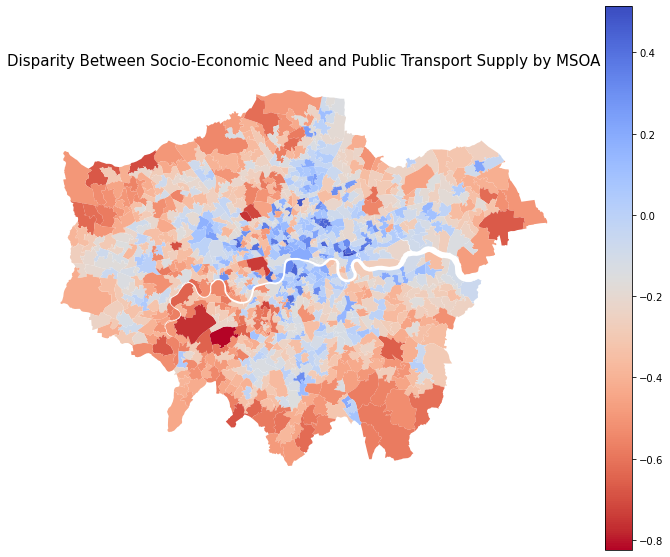

In [10]:
# 4. 地理可视化
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
final_data.plot(column='disparity_index', 
                cmap='coolwarm_r',
                legend=True, 
                ax=ax)
ax.set_title('Disparity Between Socio-Economic Need and Public Transport Supply by MSOA', fontsize=15)
ax.axis('off')
plt.show()

In [11]:
# Selecting the top 10 MSOA regions with the largest disparity
top_10_disparity = final_data.nlargest(10, 'disparity_index')[['MSOA11NM', 'disparity_index']]

In [12]:
top_10_disparity

,MSOA11NM,disparity_index
851,Tower Hamlets 020,0.514011
332,Hackney 002,0.478259
949,Westminster 023,0.460524
348,Hackney 019,0.442272
183,Camden 024,0.433830
969,Southwark 034,0.432871
346,Hackney 017,0.431656
842,Tower Hamlets 011,0.429496
849,Tower Hamlets 018,0.426262
931,Westminster 005,0.421201


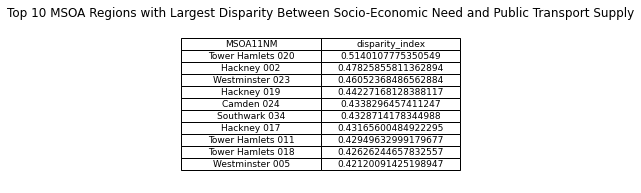

In [13]:
# Plotting the top 10 disparities as a table
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.axis('tight')
ax.axis('off')
ax.table(cellText=top_10_disparity.values, colLabels=top_10_disparity.columns, cellLoc = 'center', loc='center')
plt.title("Top 10 MSOA Regions with Largest Disparity Between Socio-Economic Need and Public Transport Supply")
plt.show()

In [14]:
# Define dependent variable and independent variables
y = final_data['STOP_DENSITY'].values.reshape(-1, 1)
X = final_data[['Household Income Estimates (2011/12);Total Median Annual Household Income (£);', 
                'Economic Activity (2011 Census);Unemployment Rate;', 
                'Qualifications (2011 Census);No qualifications;']].values
X = (X - X.mean(axis=0)) / X.std(axis=0)  # Standardizing the X variables
X = np.hstack([np.ones(y.shape), X])  # Adding constant term

In [15]:
# Extract coordinates for GWR
coords = list(zip(final_data.geometry.centroid.x, final_data.geometry.centroid.y))

In [16]:
# Choose bandwidth
selector = Sel_BW(coords, y, X, kernel='bisquare', fixed=False)
bw = selector.search()

In [17]:
# Run GWR model
gwr_model = GWR(coords, y, X, bw)
gwr_results = gwr_model.fit()

In [18]:
# Extract local coefficients
coeffs = gwr_results.params

In [19]:
# Add local coefficients to the GeoDataFrame
variables = ['Intercept', 'Income', 'Unemployment', 'No Qualifications']
for i, var in enumerate(variables):
    final_data[f'local_coeff_{var}'] = coeffs[:, i]

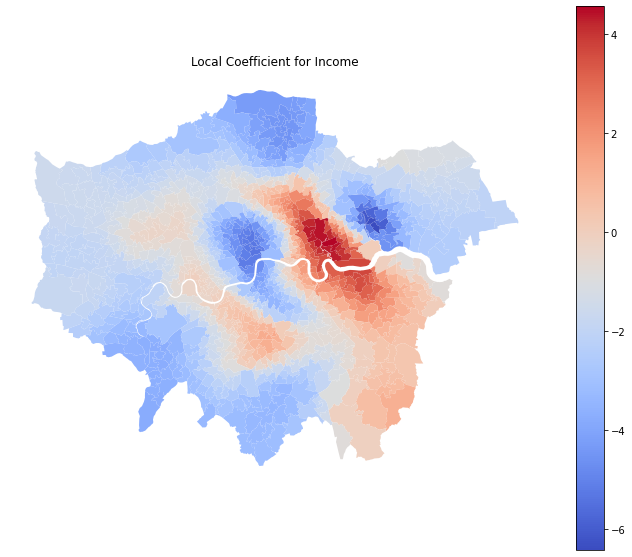

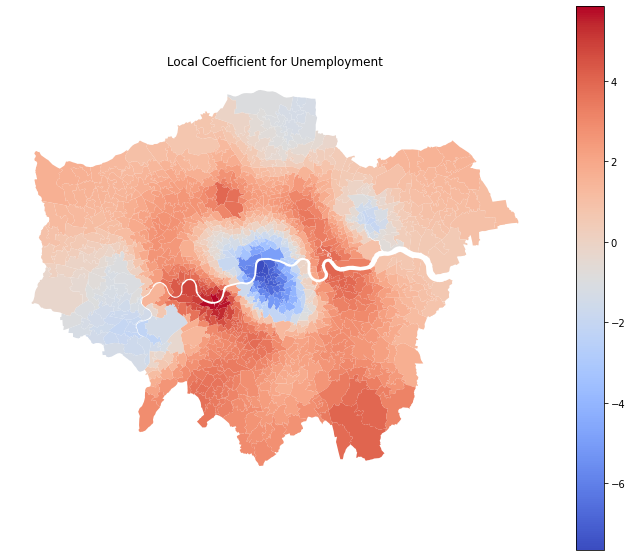

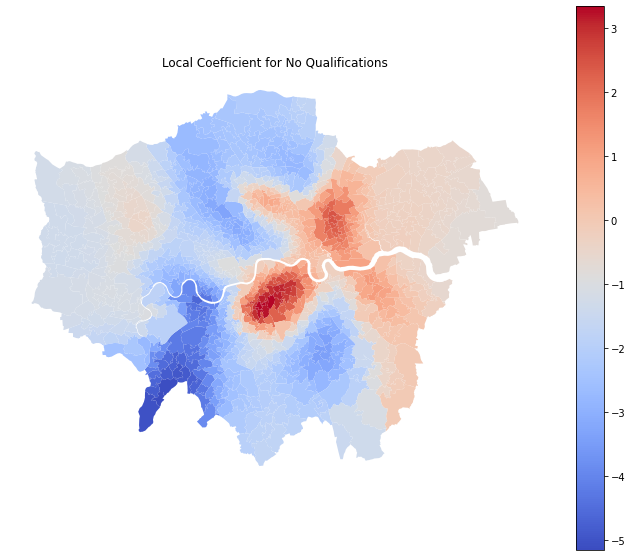

In [20]:
# Visualize the local coefficients for each variable
for var in variables[1:]:  # Excluding the intercept
    fig, ax = plt.subplots(figsize=(12, 10))
    final_data.plot(column=f'local_coeff_{var}', cmap='coolwarm', legend=True, ax=ax)
    ax.set_title(f'Local Coefficient for {var}')
    ax.axis('off')
    plt.show()